
# Session 8 — Discrete Random Variables: Simulation Lab


In [6]:

import numpy as np
import math
import matplotlib.pyplot as plt
import random


## Discrete Uniform

**Task:**

Simulate N draws from a fair die X ∈ {1,2,3,4,5,6}.  
Then compute empirical mean/variance and compare to theoretical values.  
Finally, plot CDF vs theoretical CDF.


=== Discrete Uniform (Die) ===
N = 100000
Empirical mean     = 3.498460
Empirical variance = 2.920718
Theoretical mean   = 3.500000
Theoretical var    = 2.916667


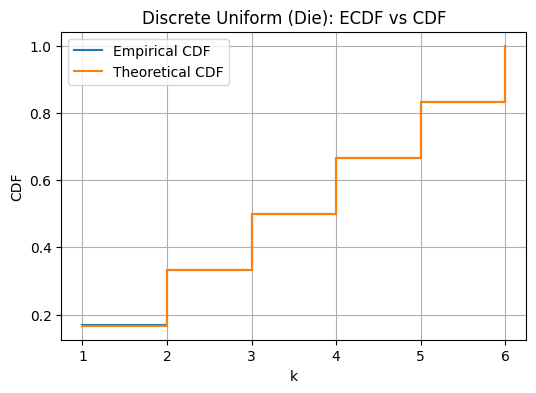

In [12]:

# Parameters
a, b = 1, 6  # fair die

# Parameters
N = 100_000

# Simulate N die rolls (values in {1,...,6})
samples = [random.randint(1, 6) for _ in range(N)]

# Empirical mean and *population* variance (to compare with theory)
emp_mean = np.mean(samples)
emp_var = np.var(samples)

# Theoretical values
n = b - a + 1
th_mean = (a + b) / 2
th_var = (n**2 - 1) / 12

print("=== Discrete Uniform (Die) ===")
print(f"N = {N}")
print(f"Empirical mean     = {emp_mean:.6f}")
print(f"Empirical variance = {emp_var:.6f}")
print(f"Theoretical mean   = {th_mean:.6f}")
print(f"Theoretical var    = {th_var:.6f}")

# empirical CDF
possibility = list(range(1, 7))
#  counts
counts = [0] * 6
for x in samples:
    counts[x - 1] += 1

cum_counts = np.cumsum(counts)
ecdf = cum_counts / cum_counts[-1]

# Theoretical CDF: equal jumps of 1/6
cdf_vals = [i / 6 for i in range(1, 7)]

# 5) Plot ECDF vs Theoretical CDF
plt.figure(figsize=(6,4))
plt.step(possibility, ecdf, where="post", label="Empirical CDF")
plt.step(possibility, cdf_vals, where="post", label="Theoretical CDF")
plt.title("Discrete Uniform (Die): ECDF vs CDF")
plt.xlabel("k")
plt.ylabel("CDF")
plt.legend()
plt.grid(True)
plt.show()




## Binomial

**Tasks**

1) Simulate N draws from Binomial(n, p) by summing n Bernoulli trials per sample.
2) Compute empirical mean and  variance, compare with theory.
3) Build empirical CDF  and compare with the theoretical CDF.
4) Plot them.

Empirical mean     = 6.012530
Empirical variance = 4.233673
Theoretical mean   = 6.000000
Theoretical var    = 4.200000


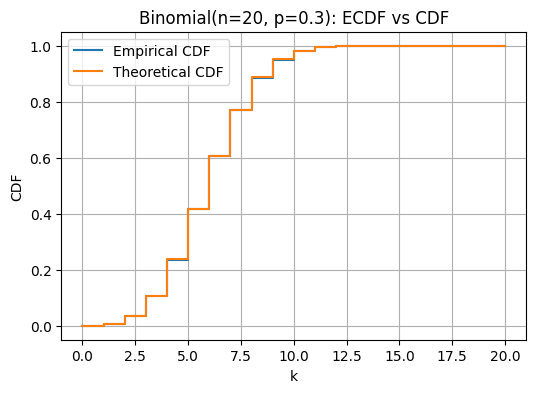

In [34]:

# Parameters
n=20 #number of trials
p=0.3 # probability

# Simulation
samples = []
for _ in range(N):
    k = 0
    for _ in range(n):
        if random.random() < p:
            k += 1
    samples.append(k)

# Empirical stats
emp_mean = np.mean(samples)
emp_var = np.var(samples)

# Theoretical stats
th_mean = n * p
th_var = n * p * (1 - p)

print(f"Empirical mean     = {emp_mean:.6f}")
print(f"Empirical variance = {emp_var:.6f}")
print(f"Theoretical mean   = {th_mean:.6f}")
print(f"Theoretical var    = {th_var:.6f}")


ntrials = list(range(0, n + 1))
counts = [0] * (n + 1)
for x in samples:
    counts[x] += 1

cum_counts = np.cumsum(counts)
ecdf_vals = cum_counts / cum_counts[-1]

# Theoretical CDF: build pmf with combinations, then cumsum
pmf = [math.comb(n, k) * (p ** k) * ((1 - p) ** (n - k)) for k in ntrials]
cdf_vals = np.cumsum(pmf)

# 5) Plot ECDF vs Theoretical CDF
plt.figure(figsize=(6,4))
plt.step(ntrials, ecdf_vals, where="post", label="Empirical CDF")
plt.step(ntrials, cdf_vals, where="post", label="Theoretical CDF")
plt.title(f"Binomial(n={n}, p={p}): ECDF vs CDF")
plt.xlabel("k")
plt.ylabel("CDF")
plt.legend()
plt.grid(True)
plt.show()

**Task**

Here you will do somethign similar but we will use a python library called scipy.stats.

For many distribution, you can calculate the pdf, cdf and create a sample from a distribution

Here you will use:

- from scipy.stats import binom
- binom.pdf

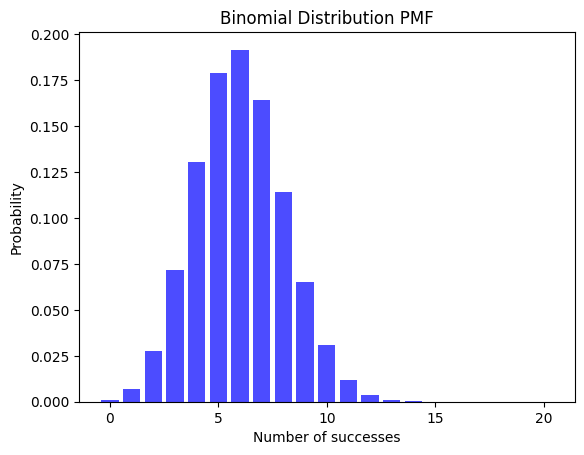

In [35]:
from scipy.stats import binom

# Parameters
n = 20  # Number of trials
p = 0.3  # Probability of success

# Values for which we want to calculate PMF
x = np.arange(0, n + 1)
# Calculate PMF
pmf_values = binom.pmf(x, n, p)

# Plot PMF
plt.bar(x, pmf_values, color='blue', alpha=0.7)
plt.xlabel('Number of successes')
plt.ylabel('Probability')
plt.title('Binomial Distribution PMF')
plt.show()

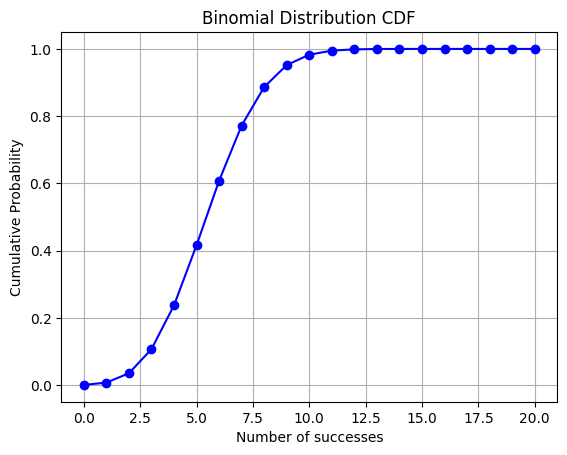

In [36]:
# Values for which we want to calculate CDF
x = np.arange(0, n + 1)
# Calculate CDF
cdf_values = binom.cdf(x, n, p)

# Plot CDF
plt.plot(x, cdf_values, marker='o', linestyle='-', color='blue')
plt.xlabel('Number of successes')
plt.ylabel('Cumulative Probability')
plt.title('Binomial Distribution CDF')
plt.grid()
plt.show()

Let X=number of heads in n=10 flips. The coin is fair, therefore p=0.5

- What is the probability of getting three heads?

- What is the probability of getting at most three head or at least seven heads?

Use binom.pdf, binom.cdf for the theorticial values,
and then simulation using binom.rvs

In [57]:
N = 200_000
n=10
p=0.5
samples = binom.rvs(n, p, size=N)


#What is the probability of getting three heads?
pmf3_th = binom.pmf(3, n, p)
pmf3_simu=(samples==3).mean()


print(f"the probability of getting three heads (simu) = {pmf3_simu:.6f}")
print(f"the probability of getting three heads (theoritical) = {pmf3_th:.6f}")

#What is the probability of getting at most three head or at least seven heads?
proba_union_sim = ((samples <= 3) | (samples >= 7)).mean()

# CDF
cdf_le3 = binom.cdf(3, n, p)          # P(X <= 3)
cdf_ge7 = 1 - binom.cdf(6, n, p)      # P(X >= 7)

print(f"the probability of getting three heads (simu) = {proba_union_sim:.6f}")
print(f"the probability of getting three heads (theoritical) = {cdf_le3+cdf_ge7:.6f}")

the probability of getting three heads (simu) = 0.117495
the probability of getting three heads (theoritical) = 0.117188
the probability of getting three heads (simu) = 0.343160
the probability of getting three heads (theoritical) = 0.343750



## Geometric — Trials until first success

**Tasks**

1) Simulate N draws from Geometric(p) **as trials until first success**
2) Compute empirical mean and  variance, compare with theory.

In [27]:

# Parameters
p = 0.2

samples = []
for _ in range(N):
    k = 1
    while random.random() >= p:
        k += 1
    samples.append(k)

#Emperical
emp_mean = np.mean(samples)
emp_var  = np.var(samples)


# Theoretical stats
th_mean = 1 / p
th_var = (1 - p) / (p**2)

print(f"Empirical mean     = {emp_mean:.6f}")
print(f"Empirical variance = {emp_var:.6f}")
print(f"Theoretical mean   = {th_mean:.6f}")
print(f"Theoretical var    = {th_var:.6f}")



Empirical mean     = 5.010040
Empirical variance = 20.174139
Theoretical mean   = 5.000000
Theoretical var    = 20.000000



## Poisson

- Plot the PMF for different values of lambda
using from scipy.stats import poisson

- Simulate a random sample using poisson.rvs

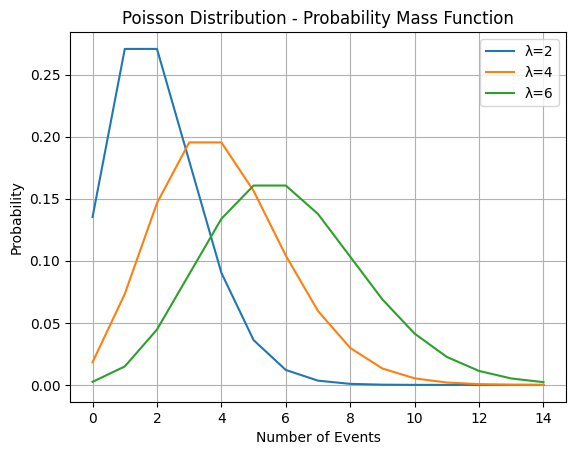

In [28]:

from scipy.stats import poisson

# Your lambda values
lambdas = [2, 4, 6]

# Range of possible event outcomes
x = np.arange(0, 15)

# Plot the Poisson PMF for different λ values
for lam in lambdas:
    pmf = poisson.pmf(x, lam)
    plt.plot(x, pmf, label=f'λ={lam}')

plt.title('Poisson Distribution - Probability Mass Function')
plt.xlabel('Number of Events')
plt.ylabel('Probability')
plt.legend()
plt.grid()
plt.show()

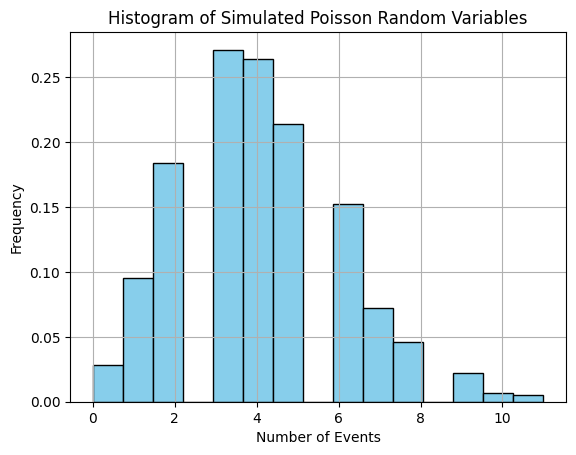

In [30]:
# Generate random samples from a Poisson distribution
# Example: 1,000 instances of event counts where the average rate of occurrence is λ=4
random_samples = poisson.rvs(4, size=1000)

# Visualize the results using a histogram
plt.hist(random_samples, bins=15, color='skyblue', edgecolor='black', density=True)
plt.title('Histogram of Simulated Poisson Random Variables')
plt.xlabel('Number of Events')
plt.ylabel('Frequency')
plt.grid()
plt.show()

Suppose a call center averages 20 calls per hour (λ=20) and max calls of 41. Using the Poisson distribution,  predict the probability of receiving 25 calls in an hour.

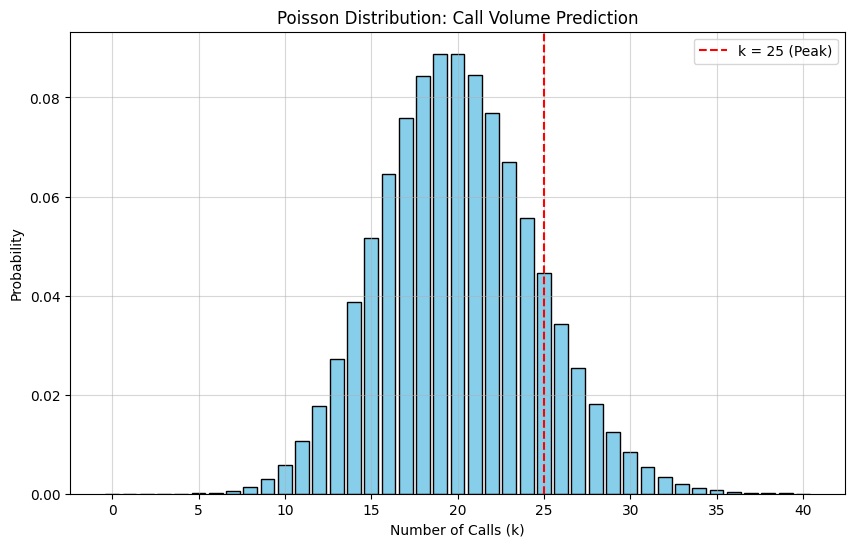

Probability of receiving exactly 25 calls in an hour: 0.0446
Probability of receiving 25 or fewer calls: 0.8878


In [31]:
# Parameters
lambda_value = 20  # Average calls per hour
k_values = np.arange(0, 41, 1)  # Number of calls to consider

# Calculate Poisson PMF
pmf_values = poisson.pmf(k_values, lambda_value)

# Plotting the distribution
plt.figure(figsize=(10, 6))
plt.bar(k_values, pmf_values, color='skyblue', edgecolor='black')
plt.axvline(x=25, color='red', linestyle='--', label='k = 25 (Peak)')
plt.title('Poisson Distribution: Call Volume Prediction')
plt.xlabel('Number of Calls (k)')
plt.ylabel('Probability')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

# Probability of exactly 25 calls
prob_25_calls = poisson.pmf(25, lambda_value)
print(f"Probability of receiving exactly 25 calls in an hour: {prob_25_calls:.4f}")

# Cumulative probability for <= 25 calls
cum_prob_up_to_25 = poisson.cdf(25, lambda_value)
print(f"Probability of receiving 25 or fewer calls: {cum_prob_up_to_25:.4f}")


## Geometric

You select randomly people on a random street in Madrid until you find a person who attended the last home football game. Let, the probability that he succeeds in finding such a person, equal 0.20. And, let X denote the number of people you select until you find his first success.

- What is the probability that you must select 4 people before you find one who attended the last home football game?


- Now, how many people should we expect you need to select before you find one who attended the last home football game?

In [46]:
from scipy.stats import geom

p = 0.20
k = 4
N=100000


#Calculate the pmf and cdf
pmf_k = geom.pmf(k, p)
cdf_k = geom.cdf(k, p)

#Generate N=100000 samples
samples = geom.rvs(p, size=N)

#probability that you must select 4 people
emp_pmf_k = (samples == k).mean()
emp_mean = np.mean(samples)
emp_var  = np.var(samples)


print("\nQuestion 1: Probability the first success is on the 4th person (X=4)")
print(f"P(X=4) = (1-p)^(4-1) * p = {(1-p)**3 * p:.6f}")
print(f"Simulation estimate (N={N}): {emp_pmf_k:.6f}")

print("\nQuestion 2: Expected number of people until first success")
print(f"E[X] = 1/p = {1/p:.6f}")
print(f"Simulation mean: {emp_mean:.6f}")


Question 1: Probability the first success is on the 4th person (X=4)
P(X=4) = (1-p)^(4-1) * p = 0.102400
Simulation estimate (N=100000): 0.102670

Question 2: Expected number of people until first success
E[X] = 1/p = 5.000000
Simulation mean: 5.018750


np.int64(10396)